<a href="https://colab.research.google.com/github/luiscastaned/pfam-domain-search-EVs-Entamoeba-histolytica-Sharma/blob/main/PFAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Instalar dependencias y crear carpetas
# Ejecuta esta celda primero. Tarda unos minutos la primera vez.

import os, subprocess, sys, textwrap, pathlib

# Instalar HMMER y Python libs
if not (pathlib.Path("/usr/bin/hmmscan").exists()):
    !apt-get update -qq
    !apt-get install -y -qq hmmer

!pip -q install pandas matplotlib

# Crear estructura de salida
OUTDIR = "pfam_out"
os.makedirs(OUTDIR, exist_ok=True)
print(f"[OK] Carpeta de salida: {OUTDIR}")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libdivsufsort3:amd64.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../libdivsufsort3_2.0.1-5_amd64.deb ...
Unpacking libdivsufsort3:amd64 (2.0.1-5) ...
Selecting previously unselected package hmmer.
Preparing to unpack .../hmmer_3.3.2+dfsg-1_amd64.deb ...
Unpacking hmmer (3.3.2+dfsg-1) ...
Setting up libdivsufsort3:amd64 (2.0.1-5) ...
Setting up hmmer (3.3.2+dfsg-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link


In [2]:
# @title Descargar Pfam-A.hmm automáticamente (opcional)
# Si ya subiste Pfam-A.hmm omite esta celda.

import os, urllib.request

PFAM_URL = "https://ftp.ebi.ac.uk/pub/databases/Pfam/current_release/Pfam-A.hmm.gz"
HMM_GZ = "Pfam-A.hmm.gz"
HMM = "Pfam-A.hmm"

if not os.path.exists(HMM):
    if not os.path.exists(HMM_GZ):
        print("[INFO] Descargando Pfam-A.hmm.gz (esto tardará)...")
        urllib.request.urlretrieve(PFAM_URL, HMM_GZ)
        print("[OK] Descargado:", HMM_GZ)
    print("[INFO] Descomprimiendo...")
    !gunzip -f Pfam-A.hmm.gz
    print("[OK] Listo:", HMM)
else:
    print("[OK] Ya existe Pfam-A.hmm")


[INFO] Descargando Pfam-A.hmm.gz (esto tardará)...
[OK] Descargado: Pfam-A.hmm.gz
[INFO] Descomprimiendo...
[OK] Listo: Pfam-A.hmm


In [3]:
# @title Subir FASTA y definir parámetros del pipeline

from google.colab import files
import os

print("📁 Sube tu archivo FASTA (por ejemplo: proteoma.faa)")
uploaded = files.upload()

# Detectar el nombre del archivo subido
if len(uploaded) == 0:
    raise ValueError("No se subió ningún archivo FASTA.")
else:
    FASTA = list(uploaded.keys())[0]
    print(f"[OK] Archivo FASTA cargado: {FASTA}")

# === Parámetros del pipeline ===
PFAM_HMM = "Pfam-A.hmm"  # Ruta a la base Pfam (debe existir o descargarse)
CPU = 8                  # Número de hilos de CPU a usar
MINCOV = 0.50            # Cobertura mínima sobre el HMM (0–1)
MAXIE = 1e-5             # i-Evalue máximo permitido
TOPN = 20                # Número de dominios a graficar

print(f"""
✅ Parámetros definidos:
FASTA   = {FASTA}
PFAM_HMM= {PFAM_HMM}
CPU     = {CPU}
MINCOV  = {MINCOV}
MAXIE   = {MAXIE}
TOPN    = {TOPN}
""")


📁 Sube tu archivo FASTA (por ejemplo: proteoma.faa)


Saving proteoma.faa to proteoma.faa
[OK] Archivo FASTA cargado: proteoma.faa

✅ Parámetros definidos:
FASTA   = proteoma.faa
PFAM_HMM= Pfam-A.hmm
CPU     = 8
MINCOV  = 0.5
MAXIE   = 1e-05
TOPN    = 20



In [4]:
# @title Ejecutar hmmpress + hmmscan
import os, pathlib, subprocess

assert pathlib.Path(FASTA).exists(), f"No se encontró {FASTA}. Súbelo o corrige la ruta."
assert pathlib.Path(PFAM_HMM).exists(), f"No se encontró {PFAM_HMM}. Súbelo/descárgalo."

print("[INFO] hmmpress (idempotente)")
!hmmpress "{PFAM_HMM}" || true

DOMTBL = f"{OUTDIR}/pfam.domtblout"
LOG = f"{OUTDIR}/pfam.hmmscan.log"

print("[INFO] hmmscan corriendo...")
!hmmscan --cpu {CPU} --domtblout "{DOMTBL}" "{PFAM_HMM}" "{FASTA}" > "{LOG}"

print("[OK] domtblout:", DOMTBL)
print("[OK] log:", LOG)


[INFO] hmmpress (idempotente)
Working...    done.
Pressed and indexed 24736 HMMs (24736 names and 24736 accessions).
Models pressed into binary file:   Pfam-A.hmm.h3m
SSI index for binary model file:   Pfam-A.hmm.h3i
Profiles (MSV part) pressed into:  Pfam-A.hmm.h3f
Profiles (remainder) pressed into: Pfam-A.hmm.h3p
[INFO] hmmscan corriendo...
[OK] domtblout: pfam_out/pfam.domtblout
[OK] log: pfam_out/pfam.hmmscan.log


In [5]:
# @title Definir funciones de parseo, filtrado y exportación
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_fasta_lengths(fasta_path):
    lengths = {}
    with open(fasta_path, 'r', encoding='utf-8') as fh:
        seq_id = None; seq_len = 0
        for line in fh:
            if line.startswith('>'):
                if seq_id is not None:
                    lengths[seq_id] = seq_len
                seq_id = line[1:].strip().split()[0]
                seq_len = 0
            else:
                seq_len += len(line.strip())
        if seq_id is not None:
            lengths[seq_id] = seq_len
    return lengths

def parse_domtblout(domtbl_path):
    rows = []
    with open(domtbl_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            if not line.strip() or line.startswith('#'):
                continue
            parts = line.strip().split()
            if len(parts) < 23:
                continue
            fixed = parts[:22]
            descr = " ".join(parts[22:]) if len(parts) > 22 else ""
            try:
                row = {
                    "hmm_name": fixed[0],
                    "hmm_acc": fixed[1],
                    "hmm_len": int(fixed[2]),
                    "seq_id": fixed[3],
                    "seq_acc": fixed[4],
                    "seq_len": int(fixed[5]),
                    "seq_eval": float(fixed[6]),
                    "seq_score": float(fixed[7]),
                    "seq_bias": float(fixed[8]),
                    "dom_c_eval": float(fixed[11]),
                    "dom_i_eval": float(fixed[12]),
                    "dom_score": float(fixed[13]),
                    "dom_bias": float(fixed[14]),
                    "hmm_from": int(fixed[15]),
                    "hmm_to": int(fixed[16]),
                    "ali_from": int(fixed[17]),
                    "ali_to": int(fixed[18]),
                    "env_from": int(fixed[19]),
                    "env_to": int(fixed[20]),
                    "dom_acc_prob": float(fixed[21]),
                    "description": descr,
                }
            except ValueError:
                continue
            rows.append(row)
    return pd.DataFrame(rows)

def filter_hits(df, min_cov=0.5, max_ie=1e-5, fasta_lengths=None):
    df = df.copy()
    df["cov_hmm"] = (df["hmm_to"] - df["hmm_from"] + 1) / df["hmm_len"].clip(lower=1)
    if fasta_lengths is not None:
        df["cov_seq"] = (df["env_to"] - df["env_from"] + 1) / df["seq_len"].clip(lower=1)
    else:
        df["cov_seq"] = float("nan")
    keep = (df["dom_i_eval"] <= max_ie) & (df["cov_hmm"] >= min_cov)
    return df.loc[keep].reset_index(drop=True)

def resolve_overlaps(df, iou_thresh=0.5):
    def iou(a, b):
        s1, e1 = a; s2, e2 = b
        inter = max(0, min(e1, e2) - max(s1, s2) + 1)
        len1 = e1 - s1 + 1; len2 = e2 - s2 + 1
        union = len1 + len2 - inter
        return inter / union if union > 0 else 0.0

    kept = []
    for seq_id, sub in df.groupby("seq_id", sort=False):
        sub = sub.sort_values("dom_score", ascending=False).reset_index(drop=True)
        accepted = []
        for _, r in sub.iterrows():
            span = (int(r["env_from"]), int(r["env_to"]))
            if all(iou(span, (int(x["env_from"]), int(x["env_to"]))) <= iou_thresh for _, x in pd.DataFrame(accepted).iterrows()):
                accepted.append(r)
        if accepted:
            kept.extend(accepted)
    return pd.DataFrame(kept).reset_index(drop=True)

def to_tsv(df, out_tsv):
    cols = [
        "seq_id","seq_len",
        "hmm_name","hmm_acc","hmm_len","description",
        "dom_i_eval","dom_score","dom_acc_prob",
        "hmm_from","hmm_to","ali_from","ali_to","env_from","env_to",
        "cov_hmm","cov_seq",
    ]
    df[cols].to_csv(out_tsv, sep='\t', index=False)

def to_gff3(df, out_gff):
    with open(out_gff, "w", encoding="utf-8") as g:
        g.write("##gff-version 3\n")
        for i, r in df.iterrows():
            seqid = r["seq_id"]
            start = int(r["env_from"]); end = int(r["env_to"])
            if start > end: start, end = end, start
            score = f'{r["dom_score"]:.2f}'
            source = "Pfam-HMMER"
            attrs = [
                f"ID={seqid}:dom{i+1}",
                f"Name={r['hmm_name']}",
                f"PfamAcc={r['hmm_acc']}",
                f"Desc={r['description'].replace(';','_').replace('=','_')}",
                f"iE={r['dom_i_eval']}",
                f"covHMM={r['cov_hmm']:.3f}",
            ]
            g.write("\t".join([seqid, source, "protein_domain", str(start), str(end),
                               f'{r["dom_score"]:.2f}', ".", ".", ";".join(attrs)]) + "\n")

def plot_counts(df, out_png, topn=20):
    counts = (df.groupby(["hmm_name","hmm_acc"])["seq_id"]
                .nunique().sort_values(ascending=False).head(topn))
    if counts.empty:
        print("[WARN] No hay conteos para graficar.")
        Path(out_png).touch()
        return
    plt.figure(figsize=(10, max(4, 0.4*len(counts))))
    counts.sort_values().plot(kind="barh")   # sin estilos/colores forzados
    plt.xlabel("Número de proteínas con el dominio")
    plt.ylabel("Dominio (Pfam)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


In [6]:
# @title Generar TSV, GFF3 y gráfico PNG
from pathlib import Path

DOMTBL = f"{OUTDIR}/pfam.domtblout"
OUT_TSV = f"{OUTDIR}/pfam_filtered.tsv"
OUT_GFF = f"{OUTDIR}/pfam_filtered.gff3"
OUT_PNG = f"{OUTDIR}/pfam_counts.png"

assert Path(DOMTBL).exists(), f"No existe {DOMTBL}. Corre hmmscan primero."

seq_lengths = read_fasta_lengths(FASTA)
df = parse_domtblout(DOMTBL)

if df.empty:
    print("[WARN] domtblout vacío o sin hits. Exportando archivos vacíos…")
    pd.DataFrame().to_csv(OUT_TSV, sep="\t", index=False)
    with open(OUT_GFF, "w", encoding="utf-8") as g:
        g.write("##gff-version 3\n")
    Path(OUT_PNG).touch()
else:
    # Asegurar longitudes desde FASTA
    df["seq_len"] = df["seq_id"].map(seq_lengths).fillna(df["seq_len"]).astype(int)

    # Filtrado por cobertura e i-Evalue
    df_f = filter_hits(df, min_cov=MINCOV, max_ie=MAXIE, fasta_lengths=seq_lengths)

    # Resolver solapes por proteína quedando el mejor puntaje (IoU>0.5)
    if not df_f.empty:
        df_f = resolve_overlaps(df_f, iou_thresh=0.5)

    if df_f.empty:
        print("[WARN] Sin hits tras filtrado. Exportando archivos vacíos…")
        pd.DataFrame().to_csv(OUT_TSV, sep="\t", index=False)
        with open(OUT_GFF, "w", encoding="utf-8") as g:
            g.write("##gff-version 3\n")
        Path(OUT_PNG).touch()
    else:
        to_tsv(df_f, OUT_TSV)
        to_gff3(df_f, OUT_GFF)
        plot_counts(df_f, OUT_PNG, topn=TOPN)
        display(df_f.head())

print("[OK] TSV :", OUT_TSV)
print("[OK] GFF3:", OUT_GFF)
print("[OK] PNG :", OUT_PNG)


,hmm_name,hmm_acc,hmm_len,seq_id,seq_acc,seq_len,seq_eval,seq_score,seq_bias,dom_c_eval,...,hmm_from,hmm_to,ali_from,ali_to,env_from,env_to,dom_acc_prob,description,cov_hmm,cov_seq
0,ADH_Fe_C,PF25137.1,194,EHI_150490_aldehyde-alcohol,-,870,6.400000e-69,232.0,3.3,2.700000e-72,...,2,194,658,866,657,866,0.99,"Fe-containing alcohol dehydrogenase family, C-...",0.994845,0.241379
1,Fe-ADH,PF00465.25,168,EHI_150490_aldehyde-alcohol,-,870,3.000000e-47,160.8,0.1,2.500000e-50,...,1,168,468,646,468,646,0.88,Iron-containing alcohol dehydrogenase,1.000000,0.205747
2,Aldedh,PF00171.27,461,EHI_150490_aldehyde-alcohol,-,870,8.000000e-24,84.4,6.2,3.300000e-24,...,28,290,10,273,2,279,0.88,Aldehyde dehydrogenase family,0.570499,0.319540
3,Actin,PF00022.25,410,EHI_182900_actin,-,376,4.500000e-149,496.9,0.0,8.200000e-153,...,2,410,4,376,3,376,0.98,Actin,0.997561,0.994681
4,Myosin_head,PF00063.27,679,EHI_110180_myosin,-,2151,3.000000e-246,819.4,6.2,2.000000e-249,...,1,679,102,792,102,792,0.94,Myosin head (motor domain),1.000000,0.321246


[OK] TSV : pfam_out/pfam_filtered.tsv
[OK] GFF3: pfam_out/pfam_filtered.gff3
[OK] PNG : pfam_out/pfam_counts.png


In [7]:
# @title Descargar resultados (TSV, GFF3, PNG, LOG y DOMTBL)
from google.colab import files
for path in [f"{OUTDIR}/pfam_filtered.tsv",
             f"{OUTDIR}/pfam_filtered.gff3",
             f"{OUTDIR}/pfam_counts.png",
             f"{OUTDIR}/pfam.hmmscan.log",
             f"{OUTDIR}/pfam.domtblout"]:
    if Path(path).exists():
        print("Descargando:", path)
        files.download(path)


Descargando: pfam_out/pfam_filtered.tsv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: pfam_out/pfam_filtered.gff3


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: pfam_out/pfam.domtblout


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# @title Construir matriz completa de todas las proteínas y dominios
import pandas as pd

TSV = "pfam_out/pfam_filtered.tsv"  # cambia si tu ruta es distinta
df = pd.read_csv(TSV, sep="\t")

# Crear identificador único para cada dominio
df["hmm_id"] = df["hmm_name"].astype(str) + "|" + df["hmm_acc"].astype(str)

# Matriz de presencia/ausencia (todas las proteínas y todos los dominios)
presence = (df.groupby(["seq_id", "hmm_id"])["dom_score"]
              .size().unstack(fill_value=0))
presence = (presence > 0).astype(int)

print(f"✅ Matriz completa: {presence.shape[0]} proteínas × {presence.shape[1]} dominios")


✅ Matriz completa: 31 proteínas × 52 dominios


In [10]:
# Diagnóstico de cobertura de hits
from collections import Counter

# 1) cuántas proteínas hay en el FASTA
all_len = read_fasta_lengths(FASTA)
all_ids = list(all_len.keys())
print("Proteínas en FASTA:", len(all_ids))

# 2) hits crudos (sin filtrar)
df_raw = parse_domtblout(DOMTBL)
prot_con_hit_crudo = sorted(set(df_raw["seq_id"]))
print("Proteínas con ≥1 hit (crudo):", len(prot_con_hit_crudo))

# 3) hits tras filtrado actual
df_f = filter_hits(df_raw, min_cov=MINCOV, max_ie=MAXIE, fasta_lengths=all_len)
prot_con_hit_filtrado = sorted(set(df_f["seq_id"]))
print("Proteínas con ≥1 dominio (filtrado):", len(prot_con_hit_filtrado))

# 4) cuáles faltan (0 dominios tras filtro)
faltantes = [p for p in all_ids if p not in prot_con_hit_filtrado]
print("Proteínas sin dominios tras filtro:", len(faltantes))
faltantes[:10]


Proteínas en FASTA: 40
Proteínas con ≥1 hit (crudo): 38
Proteínas con ≥1 dominio (filtrado): 31
Proteínas sin dominios tras filtro: 9


['EHI_030750_hypothetical',
 'EHI_012270_Gal/GalNAc',
 'EHI_004340_serine-threonine-isoleucine',
 'EHI_047800_hypothetical',
 'EHI_077500_galactose-specific',
 'EHI_140720_myosin',
 'EHI_083620_hypothetical',
 'EHI_098510_hypothetical',
 'EHI_166920_hypothetical']

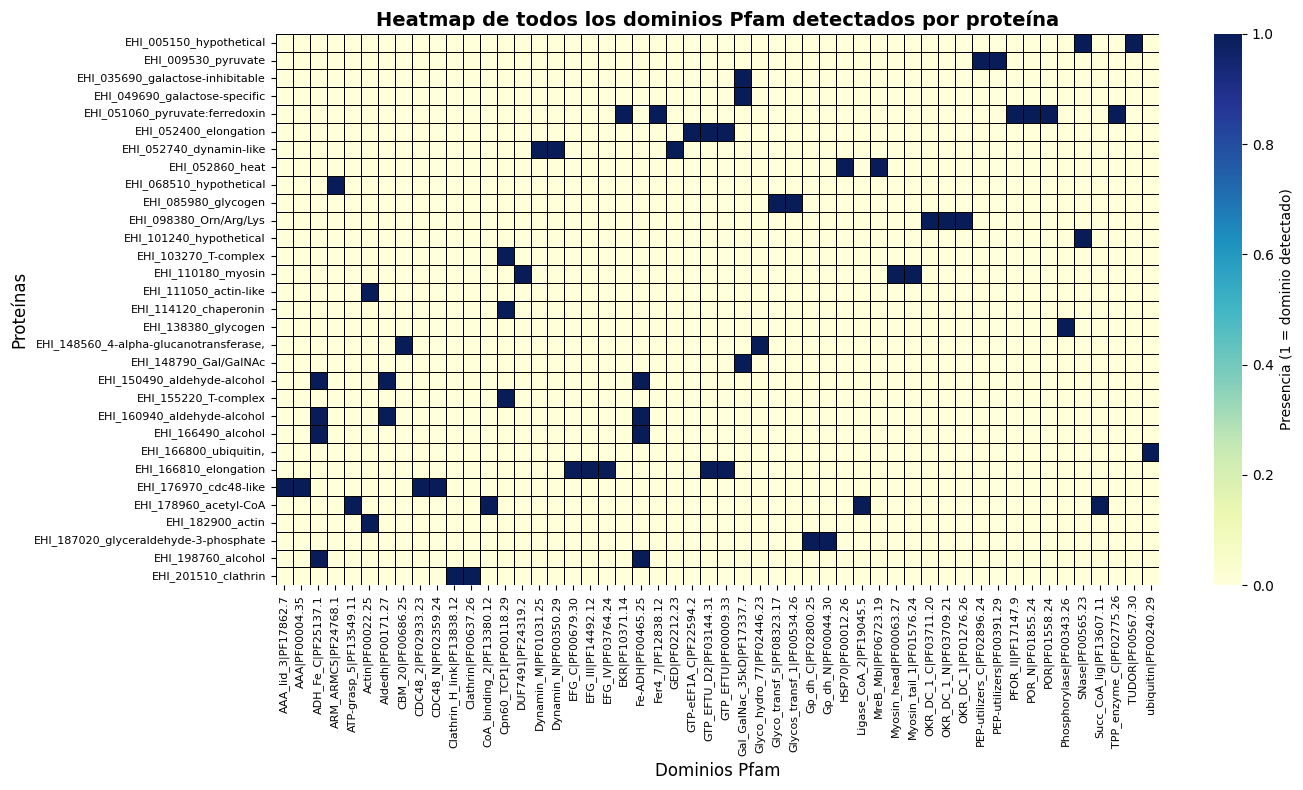

✅ Guardado: pfam_heatmap_pretty.png


In [12]:
# @title Heatmap estético y cuadriculado (todas las proteínas)
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar tamaño de la figura
plt.figure(figsize=(14, max(8, presence.shape[0]*0.25)))

# Crear heatmap con seaborn
sns.heatmap(
    presence,
    cmap="YlGnBu",          # Paleta de color: azul-verde suave
    linewidths=0.5,          # Líneas divisorias entre celdas
    linecolor="black",       # Color de las líneas divisorias
    cbar_kws={'label': 'Presencia (1 = dominio detectado)'},
    square=False             # Si lo quieres cuadriculado, pon True
)

plt.title("Heatmap de todos los dominios Pfam detectados por proteína", fontsize=14, weight='bold')
plt.xlabel("Dominios Pfam", fontsize=12)
plt.ylabel("Proteínas", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig("pfam_heatmap_pretty.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Guardado: pfam_heatmap_pretty.png")

